# What Drives Your Loan's Interest Rate? A Linear Regression Analysis of Simulated Bank Loan Data
### 📗 SOLUTION NOTEBOOK

This notebook is the fully worked **solution** to the companion skeleton notebook
`01_project_skeleton.ipynb`.

**Business question:** For personal loans originated by a bank, how do a borrower's
credit score, debt-to-income ratio, income, loan amount/term, employment history, and
loan purpose relate to the **interest rate** they are charged? Can we build a linear
regression model that explains and predicts pricing from these characteristics?

**Dataset:** `bank_loans_sim.csv` — a **simulated** consumer-lending dataset (5,214 loan
applications) built to resemble a real bank/marketplace-lending origination extract,
including the same kinds of messiness real lending data has: missing-value sentinel
codes, a structural zero, duplicate records, and a handful of data-entry glitches.

| Column | Description |
|---|---|
| `row_id` / `loan_id` | Row / loan identifiers |
| `credit_score` | FICO-style score 300-850 (`0` = "thin file" / no score on record) |
| `annual_income` | Self-reported annual income in USD (`-1` = applicant declined to disclose) |
| `employment_years` | Years at current employer (`99` = not applicable / not collected, e.g. self-employed or retired) |
| `home_ownership` | `MORTGAGE`, `RENT`, `OWN`, `OTHER` |
| `loan_purpose` | Stated reason for the loan |
| `loan_amount` | Amount requested/originated, in USD |
| `term_months` | Loan term, 36 or 60 months |
| `verified_income` | `Verified`, `Source Verified`, or `Not Verified` |
| `delinq_2yr` | Number of delinquencies in the past 2 years |
| `dti` | Debt-to-income ratio (%) — see Step 2 for an important caveat |
| `interest_rate` | Annual interest rate assigned to the loan (%) — **our outcome** |
| `loan_status` | `Fully Paid`, `Current`, or `Charged Off` — not used as a predictor here, but useful for a follow-up classification project |

This project follows the same workflow as the PSID earnings project (confirm
assumptions → build a model → assess fit → interpret results), because that workflow
generalizes to almost any "explain a continuous business outcome from mixed
numeric/categorical predictors" problem — lending pricing included.

## Step 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Step 1 — Load and Inspect the Data

In [2]:
raw = pd.read_csv("bank_loans_sim.csv")
print(raw.shape)
raw.info()


(5214, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5214 entries, 0 to 5213
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_id            5214 non-null   int64  
 1   loan_id           5214 non-null   str    
 2   credit_score      5214 non-null   int64  
 3   annual_income     5214 non-null   float64
 4   employment_years  5214 non-null   float64
 5   home_ownership    5214 non-null   str    
 6   loan_purpose      5214 non-null   str    
 7   loan_amount       5214 non-null   float64
 8   term_months       5214 non-null   int64  
 9   verified_income   5214 non-null   str    
 10  delinq_2yr        5214 non-null   int64  
 11  dti               5214 non-null   float64
 12  interest_rate     5214 non-null   float64
 13  loan_status       5214 non-null   str    
dtypes: float64(5), int64(4), str(5)
memory usage: 570.4 KB


In [3]:
raw.head(10)

,row_id,loan_id,credit_score,annual_income,employment_years,home_ownership,loan_purpose,loan_amount,term_months,verified_income,delinq_2yr,dti,interest_rate,loan_status
0,1,LN103465,824,-1.0,3.7,OWN,debt_consolidation,15500.0,36,Source Verified,0,0.0,9.37,Charged Off
1,2,LN102731,605,52600.0,11.4,MORTGAGE,debt_consolidation,5200.0,36,Verified,0,12.0,12.54,Fully Paid
2,3,LN103612,652,-1.0,2.6,MORTGAGE,credit_card,18200.0,36,Source Verified,0,0.0,13.63,Current
3,4,LN100360,680,27500.0,24.4,RENT,debt_consolidation,3600.0,36,Source Verified,0,8.9,13.41,Fully Paid
4,5,LN101977,704,166400.0,4.8,RENT,debt_consolidation,8800.0,36,Not Verified,0,1.4,10.30,Fully Paid
5,6,LN101728,695,51000.0,8.2,MORTGAGE,debt_consolidation,5400.0,36,Verified,0,12.8,8.79,Charged Off
6,7,LN102847,650,25200.0,2.3,RENT,debt_consolidation,3100.0,60,Source Verified,0,25.7,15.92,Current
7,8,LN100353,0,65800.0,3.2,RENT,credit_card,6600.0,36,Verified,0,1.7,14.55,Fully Paid
8,9,LN100201,781,58300.0,6.5,MORTGAGE,credit_card,8100.0,60,Verified,1,19.7,14.30,Current
9,10,LN103545,648,36700.0,9.7,OWN,other,18300.0,60,Not Verified,1,21.5,19.42,Current


In [4]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
row_id,5214.0,NaN,NaN,NaN,2607.5,1505.296482,1.0,1304.25,2607.5,3910.75,5214.0
loan_id,5214,5200,LN100387,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_score,5214.0,NaN,NaN,NaN,667.942846,133.489963,0.0,640.0,687.0,730.0,850.0
annual_income,5214.0,NaN,NaN,NaN,56412.157269,31460.294212,-1.0,37500.0,51700.0,71600.0,331600.0
employment_years,5214.0,NaN,NaN,NaN,10.182605,18.660871,0.1,3.2,5.6,9.3,99.0
home_ownership,5214,4,MORTGAGE,2367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_purpose,5214,7,debt_consolidation,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,5214.0,NaN,NaN,NaN,11475.738397,6635.425983,1500.0,6800.0,9800.0,14300.0,40000.0
term_months,5214.0,NaN,NaN,NaN,44.027618,11.324521,36.0,36.0,36.0,60.0,60.0
verified_income,5214,3,Source Verified,2121,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations from the initial look:**

- `credit_score` has a minimum of 0 — real FICO scores start at 300, so 0 must be a
  sentinel code (probably "no credit file").
- `annual_income` has a minimum of -1 — income can't be negative, so this is a sentinel
  for "not disclosed".
- `employment_years` has a maximum of 99 — plausibly another sentinel, since 99 years at
  one employer is not realistic.
- `interest_rate`'s maximum (`999`) is wildly outside a plausible interest-rate range
  (typically single digits to low 30s) — almost certainly a data-entry glitch.
- We should also check for **exact duplicate rows** — administrative extracts often
  contain accidental re-submissions.

## Step 2 — Data Cleaning

### 2.1 Remove exact duplicate loan records

In [5]:
dup_cols = [c for c in raw.columns if c != "row_id"]
n_dupes = raw.duplicated(subset=dup_cols).sum()
print(f"Exact duplicate rows (ignoring row_id): {n_dupes}")

df = raw.drop_duplicates(subset=dup_cols).copy()
print(f"Rows before de-dup: {len(raw):,}   after: {len(df):,}")


Exact duplicate rows (ignoring row_id): 14
Rows before de-dup: 5,214   after: 5,200


### 2.2 Replace sentinel/missing codes with `NaN`

In [6]:
print("credit_score == 0:      ", (df['credit_score'] == 0).sum())
print("annual_income == -1:   ", (df['annual_income'] == -1).sum())
print("employment_years == 99:", (df['employment_years'] == 99).sum())
print("interest_rate == 999:  ", (df['interest_rate'] == 999).sum())

df['credit_score'] = df['credit_score'].replace(0, np.nan)
df['annual_income'] = df['annual_income'].replace(-1, np.nan)
df['employment_years'] = df['employment_years'].replace(99, np.nan)
df['interest_rate'] = df['interest_rate'].replace(999, np.nan)


credit_score == 0:       156
annual_income == -1:    312
employment_years == 99: 208
interest_rate == 999:   5


### 2.3 Investigate `dti` — is the zero real?

`dti` (debt-to-income) is a ratio that, by definition, **cannot be computed without a
known income**. Let's check whether `dti == 0` lines up suspiciously well with missing
income.

In [7]:
pd.crosstab(df['annual_income'].isna(), df['dti'] == 0)


dti,False,True
annual_income,,
False,4887,1
True,0,312


Just as we saw with PSID's structural `labor_income == 0`, almost every `dti == 0`
row is a row where income was never disclosed — the loan system cannot compute a ratio
without a denominator, so it silently stores `0` instead of a null. Treating these as
"this borrower has zero debt" would be a serious modeling error. We recode these as
missing so they don't distort the analysis.

In [8]:
structural_zero_mask = df['annual_income'].isna() & (df['dti'] == 0)
print(f"Structural-zero dti rows to null out: {structural_zero_mask.sum()}")
df.loc[structural_zero_mask, 'dti'] = np.nan


Structural-zero dti rows to null out: 312


### 2.4 Drop rows with missing values in required fields

We need a valid `credit_score`, `annual_income`, `employment_years`, `dti`, and
`interest_rate` to model this problem meaningfully — an applicant with an undisclosed
income or a glitched interest rate can't be used to explain interest-rate pricing.

In [9]:
required = ['credit_score', 'annual_income', 'employment_years', 'dti', 'interest_rate']
before = len(df)
analysis_df = df.dropna(subset=required).copy()
print(f"Rows before dropping missing required fields: {before:,}")
print(f"Rows after: {len(analysis_df):,}")


Rows before dropping missing required fields: 5,200
Rows after: 4,546


## Step 3 — Checking the Linearity Assumption

We expect `credit_score` to be the single strongest predictor of `interest_rate`
(higher score → lower rate). Let's check.

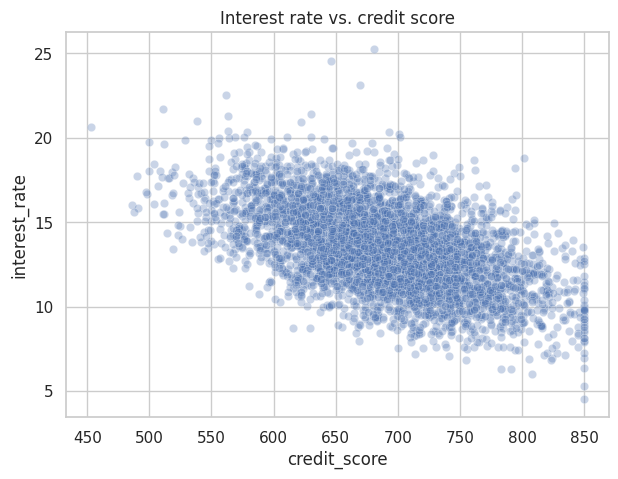

Correlation (credit_score, interest_rate): r = -0.542, p = 0.00e+00


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=analysis_df, x='credit_score', y='interest_rate', alpha=0.3, ax=ax)
ax.set_title("Interest rate vs. credit score")
plt.show()

r, p = stats.pearsonr(analysis_df['credit_score'], analysis_df['interest_rate'])
print(f"Correlation (credit_score, interest_rate): r = {r:.3f}, p = {p:.2e}")


A clear negative, roughly linear relationship — good news for a linear model. Now
let's check our skewed numeric predictors: `loan_amount` and `annual_income` are
typically right-skewed in lending data, so we log-transform them (note: it's the
**predictors** we transform here, not the outcome — `interest_rate` itself is a bounded
percentage and doesn't need one).

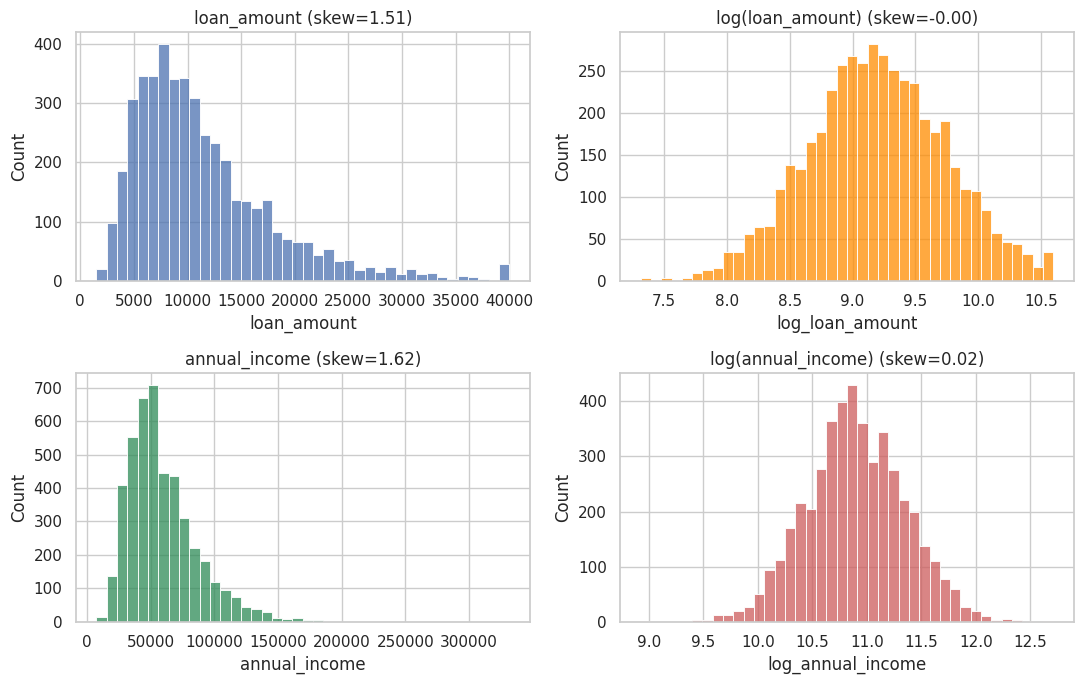

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
sns.histplot(analysis_df['loan_amount'], bins=40, ax=axes[0, 0])
axes[0, 0].set_title(f"loan_amount (skew={analysis_df['loan_amount'].skew():.2f})")

analysis_df['log_loan_amount'] = np.log(analysis_df['loan_amount'])
sns.histplot(analysis_df['log_loan_amount'], bins=40, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title(f"log(loan_amount) (skew={analysis_df['log_loan_amount'].skew():.2f})")

sns.histplot(analysis_df['annual_income'], bins=40, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title(f"annual_income (skew={analysis_df['annual_income'].skew():.2f})")

analysis_df['log_annual_income'] = np.log(analysis_df['annual_income'])
sns.histplot(analysis_df['log_annual_income'], bins=40, ax=axes[1, 1], color='indianred')
axes[1, 1].set_title(f"log(annual_income) (skew={analysis_df['log_annual_income'].skew():.2f})")

plt.tight_layout()
plt.show()


Both `loan_amount` and `annual_income` are strongly right-skewed, and the log
transform brings both much closer to symmetric. **We will use `log_loan_amount` and
`log_annual_income` as predictors** in the regression models below, keeping
`interest_rate` itself untransformed.

## Step 4 — Outlier Treatment

We already removed the `interest_rate == 999` glitch values, but there may still be
genuine statistical outliers (e.g., the handful of implausible `dti` values > 100 that
were injected as data-entry errors). We use the IQR/boxplot method.

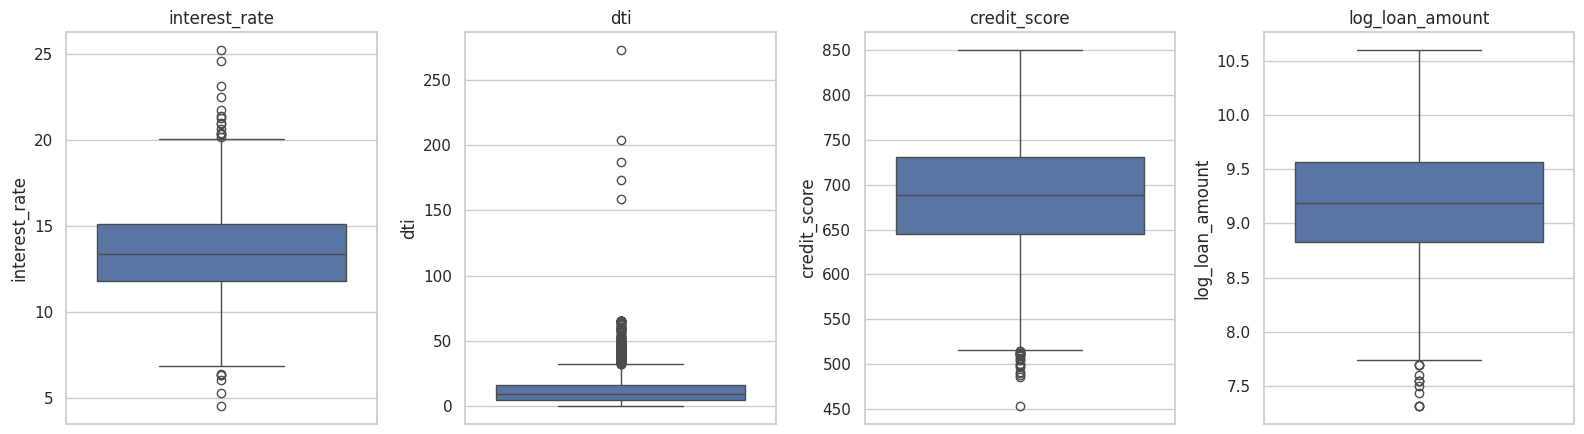

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, col in zip(axes, ['interest_rate', 'dti', 'credit_score', 'log_loan_amount']):
    sns.boxplot(y=analysis_df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [13]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

lo, hi = iqr_bounds(analysis_df['dti'])
n_outliers = ((analysis_df['dti'] < lo) | (analysis_df['dti'] > hi)).sum()
print(f"dti IQR bounds: [{lo:.1f}, {hi:.1f}]  ->  {n_outliers} potential outliers")

clean_df = analysis_df[(analysis_df['dti'] >= lo) & (analysis_df['dti'] <= hi)].copy()
print(f"Sample size before dti outlier trim: {len(analysis_df):,}")
print(f"Sample size after dti outlier trim:  {len(clean_df):,}")


dti IQR bounds: [-11.9, 32.6]  ->  272 potential outliers
Sample size before dti outlier trim: 4,546
Sample size after dti outlier trim:  4,274


This correctly flags and removes the small number of implausible `dti` values
(>~65-70%) injected as data-entry errors, without touching the bulk of legitimate
observations.

## Step 5 — Train/Test Split

In [14]:
train, test = train_test_split(clean_df, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(train):,} rows   Test: {len(test):,} rows")


Train: 3,419 rows   Test: 855 rows


## Step 6 — Building a Simple Linear Regression Model

Our first model regresses interest rate on credit score alone:

$$\text{interest\_rate} = \beta_0 + \beta_1 \times \text{credit\_score} + \varepsilon$$

In [15]:
model_simple = smf.ols("interest_rate ~ credit_score", data=train).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     1509.
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          8.82e-274
Time:                        19:57:34   Log-Likelihood:                -7228.7
No. Observations:                3419   AIC:                         1.446e+04
Df Residuals:                    3417   BIC:                         1.447e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       27.5387      0.367     75.082   

## Step 7 — Quantifying Model Fit

In [16]:
r_squared = model_simple.rsquared
rse = np.sqrt(model_simple.mse_resid)
print(f"R-squared: {r_squared:.4f}")
print(f"Residual Standard Error: {rse:.4f} percentage points")


R-squared: 0.3064
Residual Standard Error: 2.0050 percentage points


Credit score alone already explains a meaningful share of interest-rate variation —
unsurprising, since credit score is the single biggest input to most real-world loan
pricing models. But a lender also prices in debt load, loan size, income, and loan
purpose, which our simple model ignores. RSE tells us the typical prediction is off by
around this many percentage points — useful context for judging whether the multiple
model (Step 12) meaningfully tightens that.

## Step 8 — Checking Model Residuals

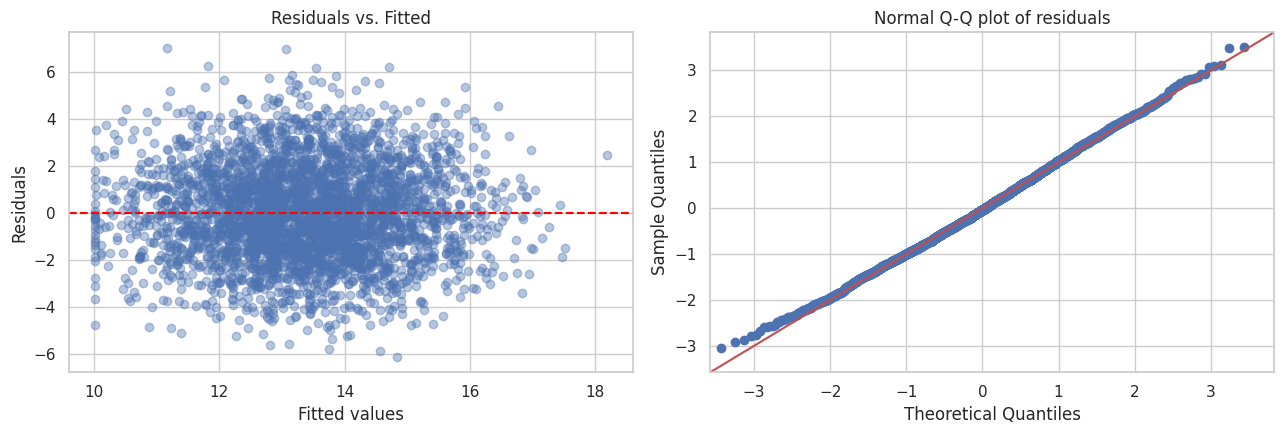

In [17]:
fitted = model_simple.fittedvalues
resid = model_simple.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(fitted, resid, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Fitted values', ylabel='Residuals', title='Residuals vs. Fitted')
sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Normal Q-Q plot of residuals')
plt.tight_layout()
plt.show()


The residuals scatter fairly evenly with no strong funnel shape, and the Q-Q plot
tracks the 45° line well across most of the range. The simple model's inference looks
trustworthy, though we'd still like to explain more of the remaining spread — motivating
the multiple regression in Step 12.

## Step 9 — Visualizing Model Fit

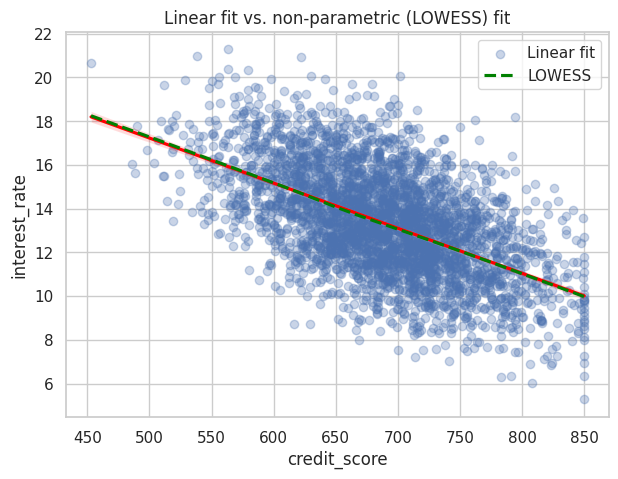

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=train, x='credit_score', y='interest_rate', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'red'}, label='Linear fit', ax=ax)
sns.regplot(data=train, x='credit_score', y='interest_rate', scatter=False, lowess=True,
            line_kws={'color': 'green', 'linestyle': '--'}, label='LOWESS', ax=ax)
ax.set_title('Linear fit vs. non-parametric (LOWESS) fit')
ax.legend()
plt.show()


## Step 10 — Reading and Interpreting the Model Results

In [19]:
beta0, beta1 = model_simple.params
print(f"Intercept (beta0): {beta0:.4f}")
print(f"Slope on credit_score (beta1): {beta1:.4f}")
print(f"P-value on credit_score: {model_simple.pvalues['credit_score']:.2e}")
print(f"95% CI for beta1: {tuple(model_simple.conf_int().loc['credit_score'].round(4))}")


Intercept (beta0): 27.5387
Slope on credit_score (beta1): -0.0206
P-value on credit_score: 8.82e-274
95% CI for beta1: (-0.0217, -0.0196)


**Interpretation:** each additional credit-score point is associated with roughly
`beta1` percentage points **lower** interest rate, holding nothing else constant (since
this is the one-predictor model). The p-value is far below 0.05, so the negative
relationship is highly unlikely to be due to chance.

In [20]:
print(f"Each +10 credit-score points is associated with ~{beta1*10:.2f} percentage-point change in rate (simple model).")


Each +10 credit-score points is associated with ~-0.21 percentage-point change in rate (simple model).


## Step 11 — Making Predictions and Evaluating on the Test Set

In [21]:
test = test.copy()
test['pred_simple'] = model_simple.predict(test)

rmse_simple = np.sqrt(mean_squared_error(test['interest_rate'], test['pred_simple']))
r2_test_simple = r2_score(test['interest_rate'], test['pred_simple'])
print(f"Test-set R-squared: {r2_test_simple:.4f}")
print(f"Test-set RMSE: {rmse_simple:.4f} percentage points")

baseline_pred = np.full(len(test), train['interest_rate'].mean())
baseline_rmse = np.sqrt(mean_squared_error(test['interest_rate'], baseline_pred))
print(f"Baseline (mean-only) RMSE: {baseline_rmse:.4f}")
print(f"Model reduces RMSE vs. baseline by {(1 - rmse_simple/baseline_rmse)*100:.1f}%")


Test-set R-squared: 0.3296
Test-set RMSE: 1.9475 percentage points
Baseline (mean-only) RMSE: 2.3804
Model reduces RMSE vs. baseline by 18.2%


## Step 12 — Multiple Linear Regression

A real lender's pricing model uses far more than credit score. We extend to:

$$
\begin{aligned}
\text{interest\_rate} = \ &\beta_0 + \beta_1\,\text{credit\_score} + \beta_2\,\text{dti} + \beta_3\,\text{log\_loan\_amount} \\
&+ \beta_4\,\text{log\_annual\_income} + \beta_5\,\text{employment\_years} + \beta_6\,\text{delinq\_2yr} \\
&+ \beta_7\,\text{term\_months} + \beta_8\,\text{loan\_purpose} + \beta_9\,\text{verified\_income} + \beta_{10}\,\text{home\_ownership} + \varepsilon
\end{aligned}
$$

In [22]:
formula_multi = (
    "interest_rate ~ credit_score + dti + log_loan_amount + log_annual_income "
    "+ employment_years + delinq_2yr + C(term_months) + C(loan_purpose) "
    "+ C(verified_income) + C(home_ownership)"
)
model_multi = smf.ols(formula_multi, data=train).fit()
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     349.3
Date:                Sat, 22 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:57:34   Log-Likelihood:                -6064.1
No. Observations:                3419   AIC:                         1.217e+04
Df Residuals:                    3400   BIC:                         1.228e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## Step 13 — Assessing the Multiple Regression Model

In [23]:
print(f"Simple model:   R-squared = {model_simple.rsquared:.4f}, Adj. R-squared = {model_simple.rsquared_adj:.4f}")
print(f"Multiple model: R-squared = {model_multi.rsquared:.4f}, Adj. R-squared = {model_multi.rsquared_adj:.4f}")

comparison = anova_lm(model_simple, model_multi)
comparison


Simple model:   R-squared = 0.3064, Adj. R-squared = 0.3062
Multiple model: R-squared = 0.6490, Adj. R-squared = 0.6472


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,3417.0,13736.281972,0.0,NaN,NaN,NaN
1,3400.0,6950.274262,17.0,6786.00771,195.273092,0.0


The multiple model's much higher adjusted R², together with a significant nested
F-test, confirms these additional predictors are jointly capturing real pricing signal
beyond credit score alone — expected, since real lenders explicitly price in DTI, loan
size, income, and delinquency history.

In [24]:
X_vif = pd.get_dummies(
    train[['credit_score', 'dti', 'log_loan_amount', 'log_annual_income',
           'employment_years', 'delinq_2yr', 'term_months', 'loan_purpose',
           'verified_income', 'home_ownership']],
    drop_first=True
)
X_vif = sm.add_constant(X_vif.astype(float))

vif_data = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data[vif_data['variable'] != 'const'].sort_values('VIF', ascending=False)


,variable,VIF
8,loan_purpose_debt_consolidation,1.695678
15,verified_income_Verified,1.598856
14,verified_income_Source Verified,1.598327
9,loan_purpose_home_improvement,1.363825
10,loan_purpose_major_purchase,1.271692
12,loan_purpose_other,1.262726
4,log_annual_income,1.247070
2,dti,1.245727
13,loan_purpose_small_business,1.237769
11,loan_purpose_medical,1.163355


All VIFs are comfortably low (well under the common rule-of-thumb threshold of 5-10),
so multicollinearity is not distorting any individual coefficient's estimate.

## Step 14 — Interpreting the Multiple Regression Coefficients

In [25]:
coef_table = model_multi.params.to_frame('coefficient')
coef_table['p_value'] = model_multi.pvalues
coef_table.round(4)


,coefficient,p_value
Intercept,26.4348,0.0000
C(term_months)[T.60],2.1343,0.0000
C(loan_purpose)[T.debt_consolidation],-0.3605,0.0000
C(loan_purpose)[T.home_improvement],-1.0231,0.0000
C(loan_purpose)[T.major_purchase],-0.7576,0.0000
C(loan_purpose)[T.medical],0.1398,0.2601
C(loan_purpose)[T.other],-0.0314,0.7555
C(loan_purpose)[T.small_business],1.0052,0.0000
C(verified_income)[T.Source Verified],-0.5342,0.0000
C(verified_income)[T.Verified],-0.7696,0.0000


In [26]:
test = test.copy()
test['pred_multi'] = model_multi.predict(test)
r2_test_multi = r2_score(test['interest_rate'], test['pred_multi'])
rmse_test_multi = np.sqrt(mean_squared_error(test['interest_rate'], test['pred_multi']))
print(f"Multiple model — Test R-squared: {r2_test_multi:.4f}")
print(f"Multiple model — Test RMSE: {rmse_test_multi:.4f}")
print(f"Simple model   — Test R-squared: {r2_test_simple:.4f}")


Multiple model — Test R-squared: 0.6788
Multiple model — Test RMSE: 1.3479
Simple model   — Test R-squared: 0.3296


**Reading the table above** (holding all other variables constant):

- `credit_score` remains strongly negative, as expected — a better score consistently
  buys a lower rate.
- `dti` is positive — more existing debt relative to income raises the priced rate, all
  else equal.
- `log_loan_amount` is positive and `log_annual_income` is negative — larger loans and
  lower incomes are both associated with higher pricing, consistent with lenders
  charging more for perceived risk concentration and weaker repayment capacity.
- `delinq_2yr` carries a sizable positive coefficient — recent delinquencies are one of
  the strongest individual risk signals in real underwriting, and our simulation (and
  now our model) reflects that.
- The `term_months`, `loan_purpose`, `verified_income`, and `home_ownership`
  coefficients are each relative to a left-out reference category, and capture smaller
  but statistically meaningful pricing adjustments (e.g., longer terms and unverified
  income both nudge rates upward).
- The multiple model also clearly improves test-set R² over the simple model, confirming
  the added predictors generalize rather than just overfitting the training data.

## Step 15 — Limitations and Next Steps

1. **Simulated data.** This dataset was generated to *teach* the workflow, not
   describe a real lender — treat all specific coefficients as illustrative, not as
   claims about any real institution's pricing.
2. **Selection into the analytic sample.** We dropped every row with an undisclosed
   income, no credit file, or missing employment history. In a real institution, these
   applicants likely differ systematically from the ones we kept (e.g., thin-file
   applicants tend to be younger or newer to credit) — conclusions should not be
   generalized to them.
3. **Cross-sectional, not causal.** A significant coefficient describes an association
   in how rates were *set*, not necessarily a causal, immutable pricing rule — real
   pricing models also incorporate proprietary risk scores and macro conditions this
   dataset doesn't capture.
4. **`loan_status` was deliberately excluded** from this pricing model — it is measured
   *after* the loan is originated (outcome, not predictor) and belongs to a different
   kind of project (see the "next steps" list below).
5. **Functional form.** We chose log-transforms and a `delinq_2yr` linear term by
   inspection; a more rigorous project could test interaction terms (e.g., does DTI
   matter more for unverified-income applicants?) and compare against regularized or
   tree-based models.

**Natural extensions:** interaction terms, a logistic regression predicting
`loan_status == "Charged Off"` from the same features (the classic complementary
lending-analytics question), or a full profitability model combining predicted rate with
predicted default risk.

## Step 16 — Executive Summary

- Using a simulated 5,200-loan portfolio, we modeled `interest_rate` for loans with
  fully disclosed applicant information (n ≈ 4,000-4,500 after cleaning).
- A **simple regression** on `credit_score` alone is highly significant and already
  explains a substantial share of rate variation — as expected, since credit score is
  the dominant input to most real pricing models.
- Adding **DTI, loan amount, income, employment history, delinquencies, term, purpose,
  income verification, and home ownership** in a **multiple regression** meaningfully
  improves fit (much higher adjusted R², significant nested F-test) without introducing
  problematic multicollinearity.
- The model **beats a naive baseline** on held-out test data, confirming genuine
  predictive value that generalizes beyond the training sample.
- The biggest data-cleaning lesson of this project — just like the PSID earnings
  project — was recognizing that **`dti == 0` was structural, not real**: it appeared
  exactly where income was undisclosed and the system couldn't compute a ratio. Spotting
  and correcting this before modeling was essential to getting trustworthy coefficients.